In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_palette("husl")


In [ ]:

df = pd.read_csv('odev_dataset/Pokemon.csv')
print(f"Veri boyutu: {df.shape}")


Veri boyutu: (800, 13)


In [3]:
# Veri setini inceleme
df.head(10)
#sütunların veri tiplerini ve eksik değerleri gösterir.

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False


In [ ]:
# Veri seti bilgileri
print("Veri seti bilgileri:")
df.info()
#sütunların veri tiplerini ve eksik değerleri gösterir.

Veri seti bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [5]:
# Eksik değerleri kontrol etme
print("Eksik değerler:")
print(df.isnull().sum())


Eksik değerler:
#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64


In [ ]:
# İstatistiksel özet
print("Sayısal değişkenlerin istatistiksel özeti:")
df.describe()
#sayısal sütunların ortalama, standart sapma, min/max gibi özet istatistikleri.

Sayısal değişkenlerin istatistiksel özeti:


,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


Legendary Pokemon dağılımı:
Legendary
False    735
True      65
Name: count, dtype: int64

Legendary Pokemon oranı: 8.12%


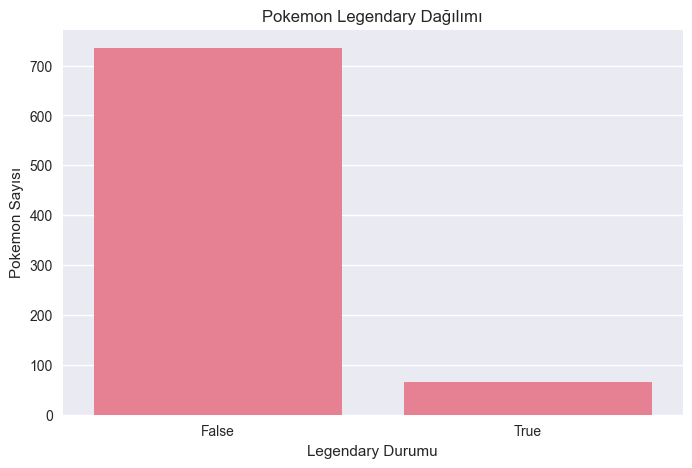

In [6]:
#Dataset'te kaç tane legendary pokemon var? 
print("Legendary Pokemon dağılımı:")
legendary_counts = df['Legendary'].value_counts()
print(legendary_counts)
print(f"\nLegendary Pokemon oranı: {legendary_counts[True] / len(df) * 100:.2f}%")

# Görselleştirme kısmı
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Legendary')
plt.title('Pokemon Legendary Dağılımı')
plt.xlabel('Legendary Durumu')
plt.ylabel('Pokemon Sayısı')
plt.show()


En yaygın Pokemon tipleri:
Type 1:
Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Rock         44
Electric     44
Ground       32
Ghost        32
Name: count, dtype: int64

Type 2 (boş olmayanlar):
Type 2
Flying      97
Ground      35
Poison      34
Psychic     33
Fighting    26
Grass       25
Fairy       23
Steel       22
Dark        20
Dragon      18
Name: count, dtype: int64


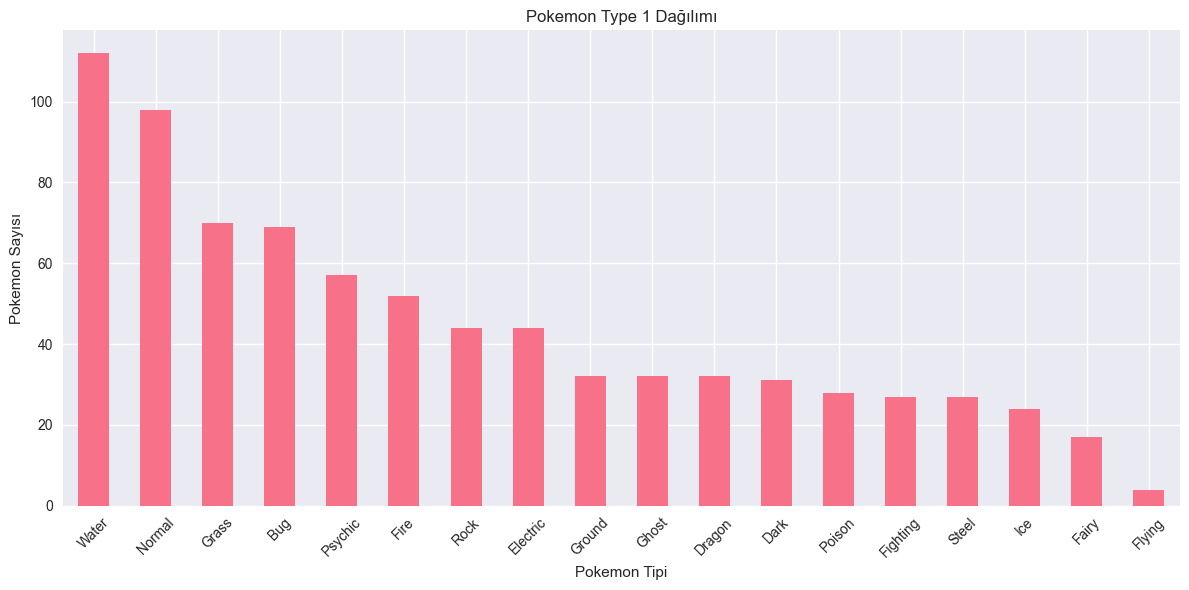

In [7]:
# Pokemonların typelarını görselleştirme    
print("En yaygın Pokemon tipleri:")
print("Type 1:")
print(df['Type 1'].value_counts().head(10))
print("\nType 2 (boş olmayanlar):")
print(df['Type 2'].value_counts().head(10))

# Type 1 dağılımını görselleştirme
plt.figure(figsize=(12, 6))
df['Type 1'].value_counts().plot(kind='bar')
plt.title('Pokemon Type 1 Dağılımı')
plt.xlabel('Pokemon Tipi')
plt.ylabel('Pokemon Sayısı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


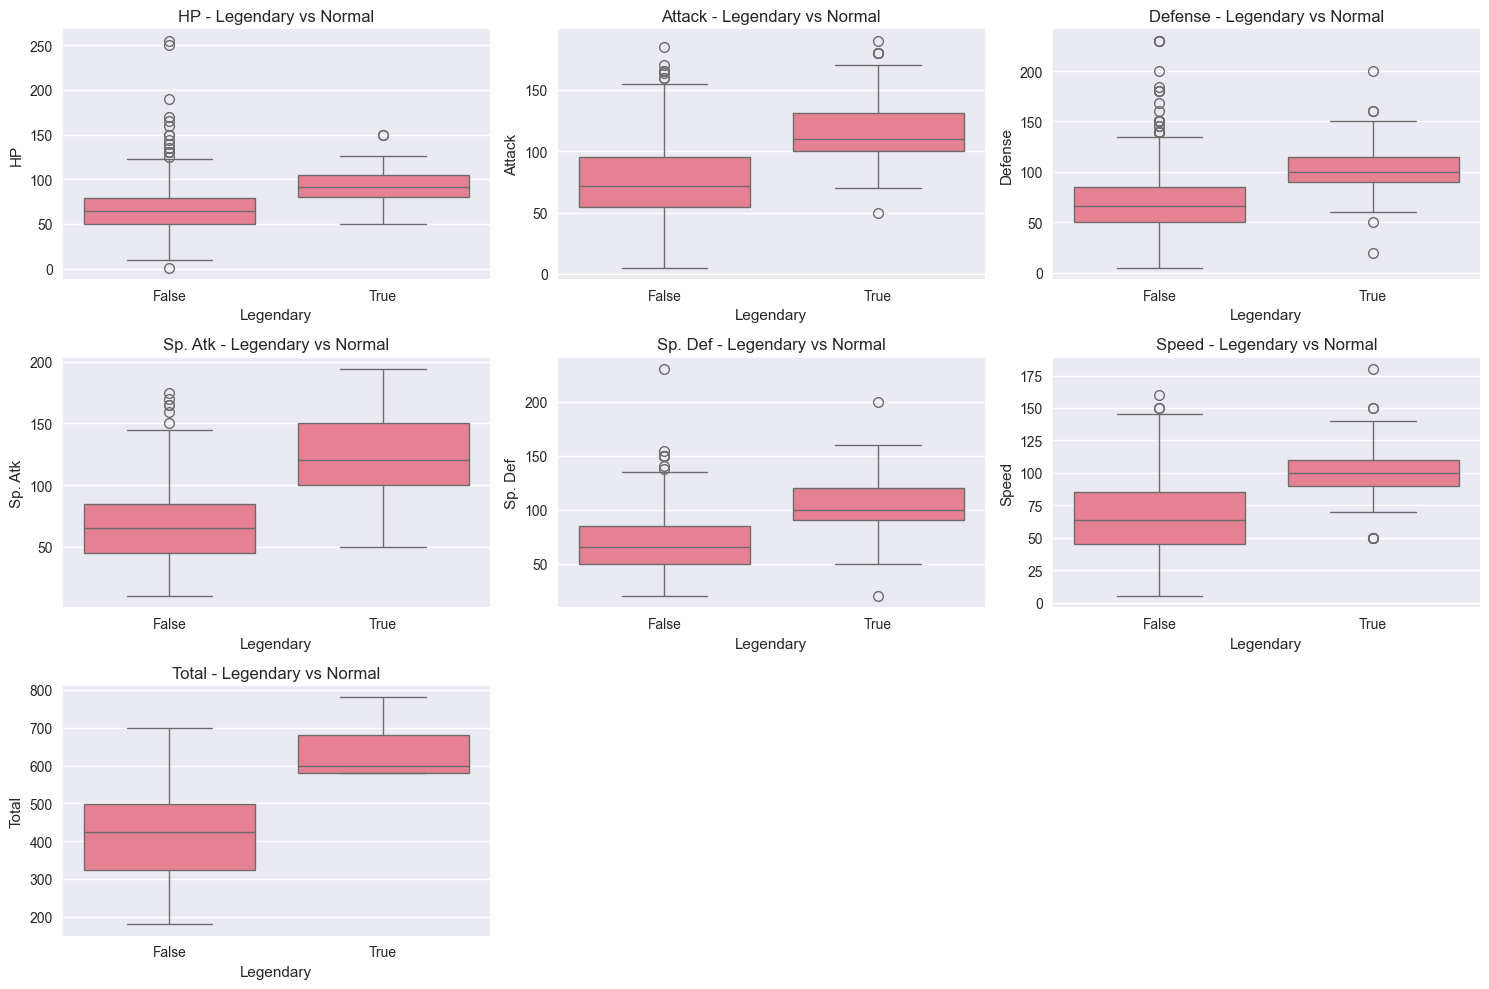

In [ ]:
# Legendary Pokemon'ları stats açısından analiz etme
stats_columns = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']
#statları tek bir değişkene atadık
# Legendary vs Normal Pokemon stats karşılaştırması
plt.figure(figsize=(15, 10))
for i, stat in enumerate(stats_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='Legendary', y=stat)
    plt.title(f'{stat} - Legendary vs Normal')
    
plt.tight_layout()
plt.show()



#Efsanevi Pokémon’lar hemen her kategoride(özellikle Sp. Atk ve Total)
#  normal Pokémon’lardan bariz şekilde üstün.
#Ayrık değerler oldukça fazla.

<Figure size 1000x600 with 0 Axes>

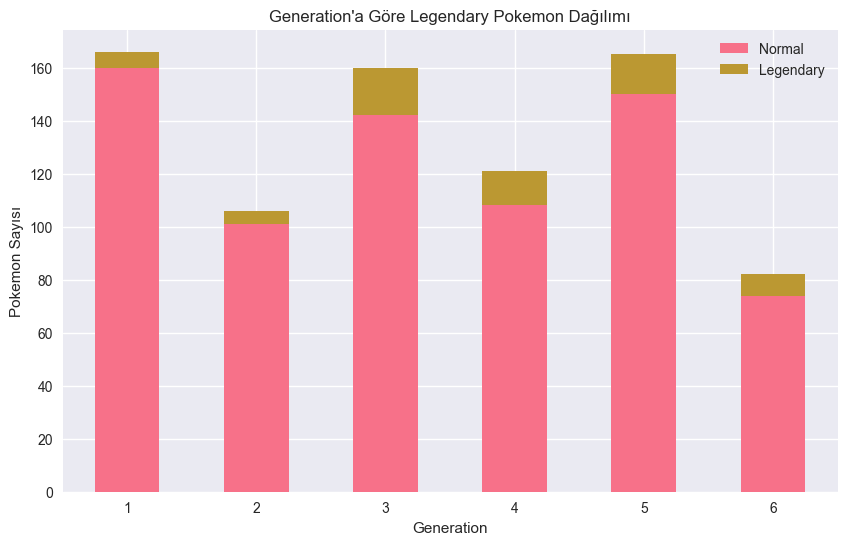

Generation'a göre Legendary Pokemon sayıları:
Generation
1     6
2     5
3    18
4    13
5    15
6     8
Name: count, dtype: int64


In [10]:
# Legendary Pokemon'ların generation dağılımı
plt.figure(figsize=(10, 6))
legendary_by_gen = df.groupby(['Generation', 'Legendary']).size().unstack()
legendary_by_gen.plot(kind='bar', stacked=True)
plt.title('Generation\'a Göre Legendary Pokemon Dağılımı')
plt.xlabel('Generation')
plt.ylabel('Pokemon Sayısı')
plt.legend(['Normal', 'Legendary'])
plt.xticks(rotation=0)
plt.show()

print("Generation'a göre Legendary Pokemon sayıları:")
print(df[df['Legendary'] == True]['Generation'].value_counts().sort_index())


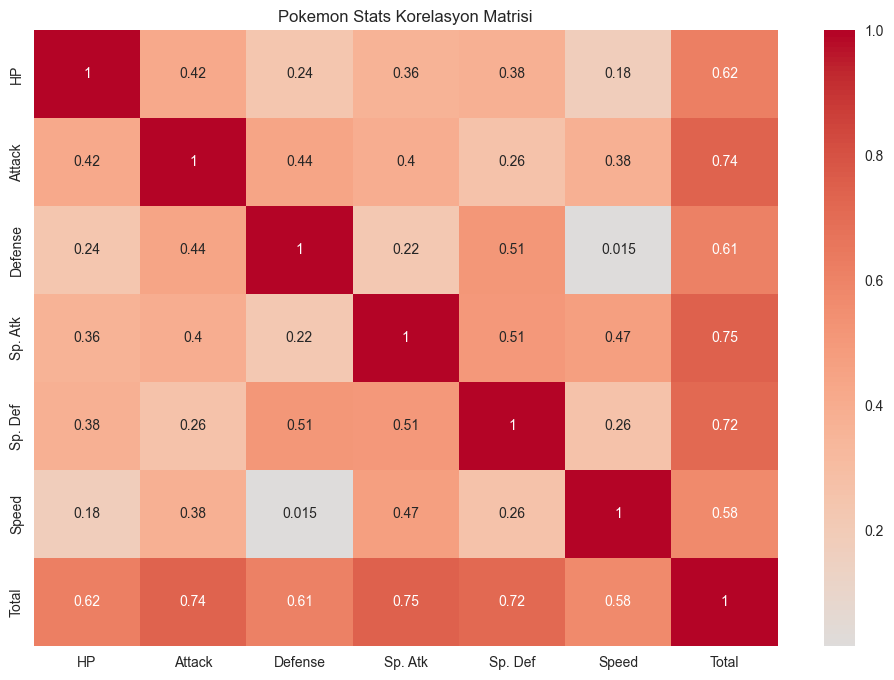

En yüksek Total stats'a sahip Pokemon'lar:
                        Name   Type 1    Type 2  Total  Legendary
163      MewtwoMega Mewtwo X  Psychic  Fighting    780       True
164      MewtwoMega Mewtwo Y  Psychic       NaN    780       True
426    RayquazaMega Rayquaza   Dragon    Flying    780       True
422      KyogrePrimal Kyogre    Water       NaN    770       True
424    GroudonPrimal Groudon   Ground      Fire    770       True
552                   Arceus   Normal       NaN    720       True
268  TyranitarMega Tyranitar     Rock      Dark    700      False
409  SalamenceMega Salamence   Dragon    Flying    700      False
413  MetagrossMega Metagross    Steel   Psychic    700      False
418        LatiasMega Latias   Dragon   Psychic    700       True


In [36]:
# Korelasyon analizi
plt.figure(figsize=(12, 8))
correlation_matrix = df[stats_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Pokemon Stats Korelasyon Matrisi')
plt.show()

# En yüksek stats'a sahip legendary Pokemon'lar
print("En yüksek Total stats'a sahip Pokemon'lar:")
print(df.nlargest(10, 'Total')[['Name', 'Type 1', 'Type 2', 'Total', 'Legendary']])


In [11]:
def preprocess_pokemon_data(df):
 
    
    # Kopya oluştur
    df_processed = df.copy()
    
    # 1. Type 2'deki NaN değerleri 'None' ile doldur
    df_processed['Type 2'] = df_processed['Type 2'].fillna('None')
    print("Type 2 eksik değerleri dolduruldu")
    
    # 2. Duplicate Pokemon'ları temizle (aynı isimde farklı formlar varsa)
    print("Orijinal veri boyutu: {df_processed.shape}")
    df_processed = df_processed.drop_duplicates(subset=['Name'], keep='first')
    print("Duplicate temizlendikten sonra: {df_processed.shape}")
    
    # 3. Özellik mühendisliği

    
    # Stats ratioları
    df_processed['Attack_Defense_Ratio'] = df_processed['Attack'] / (df_processed['Defense'] + 1)
    df_processed['SpAttack_SpDefense_Ratio'] = df_processed['Sp. Atk'] / (df_processed['Sp. Def'] + 1)
    df_processed['Physical_Special_Ratio'] = (df_processed['Attack'] + df_processed['Defense']) / (df_processed['Sp. Atk'] + df_processed['Sp. Def'] + 1)
    
    # Stats kategorileri
    df_processed['High_Total_Stats'] = (df_processed['Total'] > df_processed['Total'].quantile(0.75)).astype(int)
    df_processed['Balanced_Pokemon'] = (df_processed[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].std(axis=1) < 20).astype(int)
    
    # Type kombinasyonu
    df_processed['Type_Combination'] = df_processed['Type 1'] + '_' + df_processed['Type 2']
    df_processed['Has_Second_Type'] = (df_processed['Type 2'] != 'None').astype(int)
    
    # Generation kategorisi
    df_processed['Early_Generation'] = (df_processed['Generation'] <= 2).astype(int)
    
    # BST kategorisi (Pokemon güç seviyesi)
    df_processed['BST_Category'] = pd.cut(df_processed['Total'], 
                                         bins=[0, 300, 450, 550, 1000], 
                                         labels=['Weak', 'Average', 'Strong', 'Legendary_Level'])
    
    # 4. Kategorik değişkenleri encode etme
    le_type1 = LabelEncoder()
    le_type2 = LabelEncoder()
    le_bst = LabelEncoder()
    
    df_processed['Type1_Encoded'] = le_type1.fit_transform(df_processed['Type 1'])
    df_processed['Type2_Encoded'] = le_type2.fit_transform(df_processed['Type 2'])
    df_processed['BST_Category_Encoded'] = le_bst.fit_transform(df_processed['BST_Category'])
    
    # 5. Gereksiz sütunları kaldırma
    columns_to_drop = ['#', 'Name', 'Type 1', 'Type 2', 'Type_Combination', 'BST_Category']
    df_processed = df_processed.drop(columns_to_drop, axis=1)
    

    print("Yeni özellik sayısı: {df_processed.shape[1] - 1}")  # -1 çünkü Legendary target!!!!!!!!!!!!!!!
    
    return df_processed, le_type1, le_type2, le_bst

# Veri önişleme uygulama
df_processed, le_type1, le_type2, le_bst = preprocess_pokemon_data(df)



def preprocess_pokemon_data(df):

    # Kopya oluştur
    df_processed = df.copy()
    
    # 1. Type 2'deki NaN değerleri 'None' ile doldur
    df_processed['Type 2'] = df_processed['Type 2'].fillna('None')
    
    # 2. Duplicate Pokemon'ları temizle (aynı isimde farklı formlar varsa)
    print(f"Orijinal veri boyutu: {df_processed.shape}")
    df_processed = df_processed.drop_duplicates(subset=['Name'], keep='first')
    print(f"Duplicate temizlendikten sonra: {df_processed.shape}")
    
    # 3. Özellik mühendisliği
    # Stats ratioları
    df_processed['Attack_Defense_Ratio'] = df_processed['Attack'] / (df_processed['Defense'] + 1)
    df_processed['SpAttack_SpDefense_Ratio'] = df_processed['Sp. Atk'] / (df_processed['Sp. Def'] + 1)
    df_processed['Physical_Special_Ratio'] = (df_processed['Attack'] + df_processed['Defense']) / (df_processed['Sp. Atk'] + df_processed['Sp. Def'] + 1)
    
    # Stats kategorileri
    df_processed['High_Total_Stats'] = (df_processed['Total'] > df_processed['Total'].quantile(0.75)).astype(int)
    df_processed['Balanced_Pokemon'] = ((df_processed[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].std(axis=1)) < 20).astype(int)
    
    # Type kombinasyonu
    df_processed['Type_Combination'] = df_processed['Type 1'] + '_' + df_processed['Type 2']
    df_processed['Has_Second_Type'] = (df_processed['Type 2'] != 'None').astype(int)
    
    # Generation kategorisi
    df_processed['Early_Generation'] = (df_processed['Generation'] <= 2).astype(int)
    
    # 4. Kategorik değişkenleri encode etme
    le_type1 = LabelEncoder()
    le_type2 = LabelEncoder()
    
    df_processed['Type1_Encoded'] = le_type1.fit_transform(df_processed['Type 1'])
    df_processed['Type2_Encoded'] = le_type2.fit_transform(df_processed['Type 2'])
    
    # 5. Gereksiz sütunları kaldırma
    columns_to_drop = ['#', 'Name', 'Type 1', 'Type 2', 'Type_Combination']
    df_processed = df_processed.drop(columns_to_drop, axis=1)
    
    return df_processed, le_type1, le_type2

# Veri önişleme uygulama
df_processed, le_type1, le_type2 = preprocess_pokemon_data(df)
print(f"Final veri boyutu: {df_processed.shape}")
print(f"Özellik sayısı: {df_processed.shape[1] - 1}")  # -1 çünkü Legendary target değişken!!!!!!!!!!!!!!!

Type 2 eksik değerleri dolduruldu
Orijinal veri boyutu: {df_processed.shape}
Duplicate temizlendikten sonra: {df_processed.shape}
Yeni özellik sayısı: {df_processed.shape[1] - 1}
Orijinal veri boyutu: (800, 13)
Duplicate temizlendikten sonra: (800, 13)
Final veri boyutu: (800, 18)
Özellik sayısı: 17


In [12]:
# Yeni datasetteki column adları
print(df_processed.columns.tolist())
# legendary olan pokemonların sayımı
print(df_processed['Legendary'].value_counts())

# Özellikler ve  target değişkenini ayırma 
#Modelin neyi tahmin edecğini belirlemek için ayırıyoruz.
X = df_processed.drop('Legendary', axis=1)
y = df_processed['Legendary']




['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary', 'Attack_Defense_Ratio', 'SpAttack_SpDefense_Ratio', 'Physical_Special_Ratio', 'High_Total_Stats', 'Balanced_Pokemon', 'Has_Second_Type', 'Early_Generation', 'Type1_Encoded', 'Type2_Encoded']
Legendary
False    735
True      65
Name: count, dtype: int64


In [13]:
# Veriyi train ve test setlerine ayırma
# Bu ayrım modelin ne kadar başarılı olacaığını test etmemize olanak sağlar.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")
print(f"Eğitim setinde Legendary oranı: {y_train.sum() / len(y_train) * 100:.2f}%")
print(f"Test setinde Legendary oranı: {y_test.sum() / len(y_test) * 100:.2f}%")


Eğitim seti boyutu: (640, 17)
Test seti boyutu: (160, 17)
Eğitim setinde Legendary oranı: 8.12%
Test setinde Legendary oranı: 8.12%


In [18]:
#Modelleri tanımlama
#Pipeline kullanma sebebimiz,tek düzenli bir akışta birleştirmek.Böylece hatasız ve tekrar edilebilir hale gelir.
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(random_state=42, probability=True))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
}

print("Tanımlanan modeller:")
for name in models.keys():
    print(f"- {name}")


#Logistic Regression, sınıflandaırma modelidir.
#Basit, hızlı, yorumlanabilir.
#Küçük veri setlerinde iyi çalışır.

#Random Forest,Çok sayıda Decision Tree (karar ağacı) oluşturur, hepsinin sonucunu oylayarak karar verir.
#Her ağaç farklı veri parçalarıyla ve farklı özelliklerle eğitilir böylece çeşitlilik artar.
#Karmaşık ilişkileri öğrenebilir
#Aşırı uyuma (overfitting) karşı dayanıklı.

#Decision Tree
#Kolay görselleştirilebilir, yorumlanabilir.
#Doğrusal olmayan ilişkileri yakalayabilir.
#Tek başına kullanılırsa kolay overfit olur.

#SVM,Sınıfları ayıran en iyi çizgiyi (veya yüzeyi) bulmaya çalışır.
#Karmaşık veri yapılarında iyi çalışır.
#Az veriyle bile güçlü performans.

#KNN,Yeni bir örneğin sınıfını, en yakın K komşusunun sınıfına bakarak tahmin eder.
#Uzaklığı ölçmek için genelde Öklid mesafesi kullanılır.
#Doğrusal olmayan ilişkileri de yakalayabilir.
#Büyük veri setlerinde tahmin süresi çok uzun
#Gürültülü (noisy) verilere karşı hassas

Tanımlanan modeller:
- Logistic Regression
- Random Forest
- Decision Tree
- SVM
- KNN




 Sonuçlar:
Doğruluk (Accuracy): 0.9250 (92.5%)
ROC AUC: 0.9634

 Sınıflandırma Raporu:
              precision    recall  f1-score   support

       False       0.95      0.97      0.96       147
        True       0.55      0.46      0.50        13

    accuracy                           0.93       160
   macro avg       0.75      0.71      0.73       160
weighted avg       0.92      0.93      0.92       160



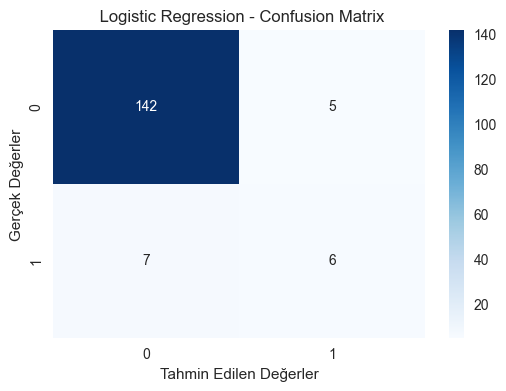



 Sonuçlar:
Doğruluk (Accuracy): 0.9437 (94.4%)
ROC AUC: 0.9819

 Sınıflandırma Raporu:
              precision    recall  f1-score   support

       False       0.96      0.98      0.97       147
        True       0.70      0.54      0.61        13

    accuracy                           0.94       160
   macro avg       0.83      0.76      0.79       160
weighted avg       0.94      0.94      0.94       160



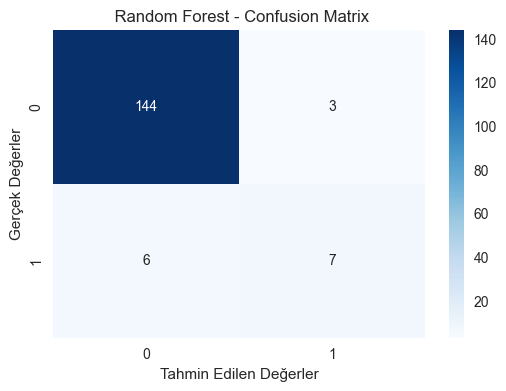



 Sonuçlar:
Doğruluk (Accuracy): 0.9437 (94.4%)
ROC AUC: 0.8642

 Sınıflandırma Raporu:
              precision    recall  f1-score   support

       False       0.98      0.96      0.97       147
        True       0.62      0.77      0.69        13

    accuracy                           0.94       160
   macro avg       0.80      0.86      0.83       160
weighted avg       0.95      0.94      0.95       160



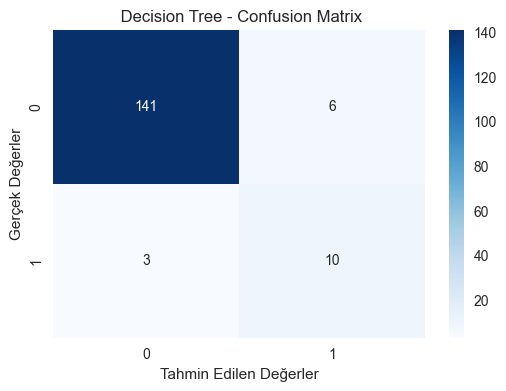



 Sonuçlar:
Doğruluk (Accuracy): 0.9187 (91.9%)
ROC AUC: 0.9602

 Sınıflandırma Raporu:
              precision    recall  f1-score   support

       False       0.94      0.98      0.96       147
        True       0.50      0.23      0.32        13

    accuracy                           0.92       160
   macro avg       0.72      0.61      0.64       160
weighted avg       0.90      0.92      0.90       160



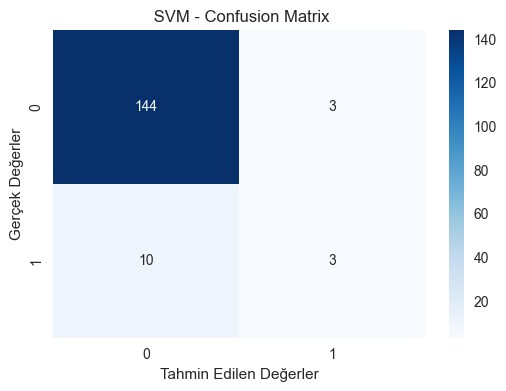



 Sonuçlar:
Doğruluk (Accuracy): 0.9313 (93.1%)
ROC AUC: 0.8721

 Sınıflandırma Raporu:
              precision    recall  f1-score   support

       False       0.96      0.97      0.96       147
        True       0.58      0.54      0.56        13

    accuracy                           0.93       160
   macro avg       0.77      0.75      0.76       160
weighted avg       0.93      0.93      0.93       160



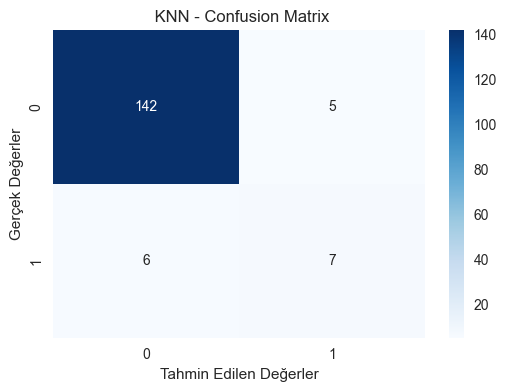


{'='*50}
Tüm modeller eğitildi ve değerlendirildi!


In [ ]:
#  Modelleri eğitme ve değerlendirme
results = {}
roc_data = {}

for name, model in models.items():
    print(f"\n{'='*50}")

    
    # Model eğitimi
    model.fit(X_train, y_train)
    
    # Tahminler
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Positive class probability
    
    # Metrikleri hesaplama
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Sonuçları kaydetme
    results[name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'classification_report': classification_report(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    # ROC curve verisini kaydet
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr}
    
    print("\n Sonuçlar:")
    print(f"Doğruluk (Accuracy): {accuracy:.4f} ({accuracy*100:.1f}%)")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("\n Sınıflandırma Raporu:")
    print(results[name]['classification_report'])
    
    # Confusion Matrix görselleştirme
    plt.figure(figsize=(6, 4))
    sns.heatmap(results[name]['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
    plt.title(f' {name} - Confusion Matrix')
    plt.ylabel('Gerçek Değerler')
    plt.xlabel('Tahmin Edilen Değerler')
    plt.show()

print("\n{'='*50}")
print("Tüm modeller eğitildi ve değerlendirildi!")


###İLK TABLO İÇİN(LOGISTIC REGRESSION)
#142 (True Negative - TN): Gerçek sınıf 0, model de 0 tahmin etmiş → Doğru negatifler.
#5 (False Positive - FP): Gerçek sınıf 0, model 1 tahmin etmiş → Yanlış pozitifler.
#7 (False Negative - FN): Gerçek sınıf 1, model 0 tahmin etmiş → Yanlış negatifler.
#6 (True Positive - TP): Gerçek sınıf 1, model 1 tahmin etmiş → Doğru pozitifler.

#Model çoğunlukla 0 sınıfını doğru tahmin ediyor (142 doğru negatif var).
#1 sınıfını tahmin etme konusunda zayıf (sadece 6 doğru pozitif, 7 yanlış negatif).
#Veri setinde 0 sınıfı baskın gibi görünüyor, bu da modelin dengesiz sınıflarda 0’ı tercih etmesine sebep olmuş olabilir.
#Yanlış pozitif sayısı (5) oldukça düşük, bu iyi bir şey.

#Model genel doğrulukta yüksek, ancak pozitif sınıfı (1) yakalama konusunda başarısı düşük.
#Bunun nedeni:
#Sınıf dengesizliği
#Logistic Regression’ın lineer sınırlara bağlı kalması
#olabilir.


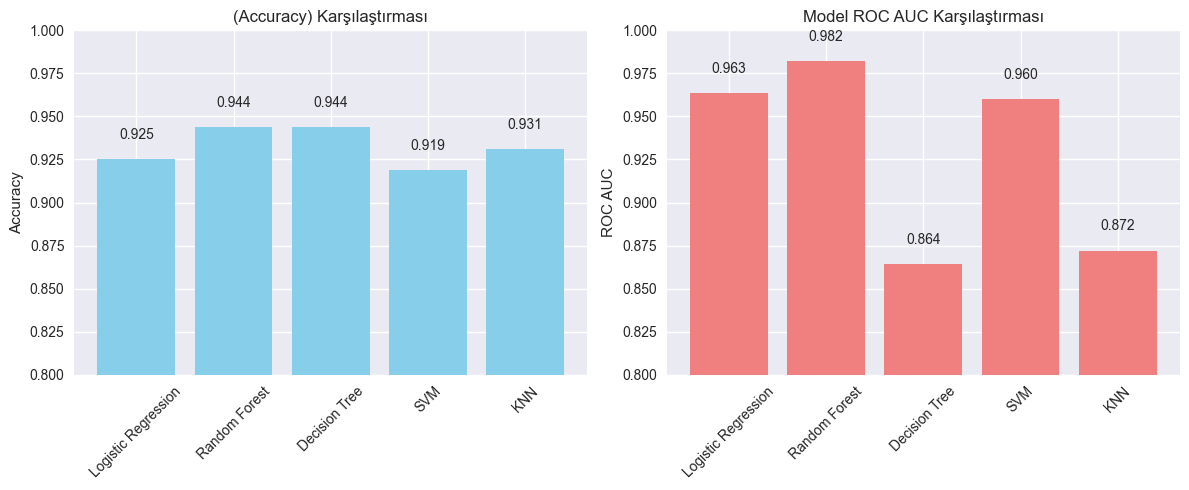

In [28]:
#  Model karşılaştırması görselleştirme
plt.figure(figsize=(12, 5))

# 1. Accuracy karşılaştırması
plt.subplot(1, 2, 1)
accuracies = {name: result['accuracy'] for name, result in results.items()}
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.title('(Accuracy) Karşılaştırması')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
for name, acc in accuracies.items():
    plt.text(name, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom')

# 2. ROC AUC karşılaştırması
plt.subplot(1, 2, 2)
roc_aucs = {name: result['roc_auc'] for name, result in results.items()}
plt.bar(roc_aucs.keys(), roc_aucs.values(), color='lightcoral')
plt.title('Model ROC AUC Karşılaştırması')
plt.ylabel('ROC AUC')
plt.xticks(rotation=45)
plt.ylim(0.8, 1.0)
for name, auc in roc_aucs.items():
    plt.text(name, auc + 0.01, f'{auc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



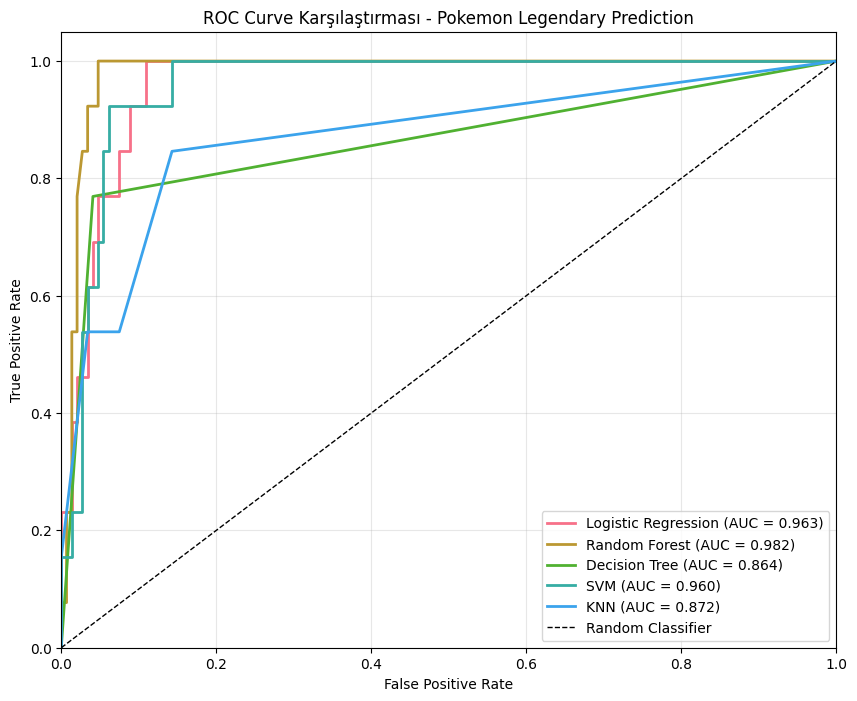

In [73]:
# ROC Curve karşılaştırması
plt.figure(figsize=(10, 8))
for name, data in roc_data.items():
    plt.plot(data['fpr'], data['tpr'], 
             label=f"{name} (AUC = {results[name]['roc_auc']:.3f})", 
             linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Karşılaştırması - Pokemon Legendary Prediction')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [30]:
# En iyi modeli bulma (ROC AUC'ye göre)
best_model_name = max(results.items(), key=lambda x: x[1]['roc_auc'])[0]
best_accuracy = results[best_model_name]['accuracy']
best_roc_auc = results[best_model_name]['roc_auc']

print(f"En iyi model: {best_model_name}")
print(f"Doğruluk: {best_accuracy:.4f}")
print(f"ROC AUC: {best_roc_auc:.4f}")

# Model performansları tablosu
print(f"\n{'='*60}")
print("TÜM MODEL PERFORMANSLARI:")
print(f"{'='*60}")
print(f"{'Model':<20} {'Accuracy':<12} {'ROC AUC':<12}")
print(f"{'-'*60}")
for name, result in results.items():
    acc = result['accuracy']
    auc = result['roc_auc']
    marker = " ⭐" if name == best_model_name else ""
    print(f"{name:<20} {acc:<12.4f} {auc:<12.4f}{marker}")


En iyi model: Random Forest
Doğruluk: 0.9437
ROC AUC: 0.9819

TÜM MODEL PERFORMANSLARI:
Model                Accuracy     ROC AUC     
------------------------------------------------------------
Logistic Regression  0.9250       0.9634      
Random Forest        0.9437       0.9819       ⭐
Decision Tree        0.9437       0.8642      
SVM                  0.9187       0.9602      
KNN                  0.9313       0.8721      


In [31]:
# Random Forest için hiperparametre optimizasyonu (genellikle en iyi performans gösterir)
print(f"\n{best_model_name} için hiperparametre optimizasyonu yapılıyor...")

# Random Forest için parametre grid'i
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Grid search
rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Grid Search başlatılıyor...")
grid_search.fit(X_train, y_train)



Random Forest için hiperparametre optimizasyonu yapılıyor...
Grid Search başlatılıyor...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [32]:
# En iyi parametreleri gösterme
print("\n" + "="*50)
print("HİPERPARAMETRE OPTİMİZASYON SONUÇLARI")
print("="*50)
print(f"En iyi parametreler:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nEn iyi cross-validation ROC AUC skoru: {grid_search.best_score_:.4f}")

# Optimize edilmiş model ile test seti tahminleri
best_model = grid_search.best_estimator_
y_pred_optimized = best_model.predict(X_test)
y_pred_proba_optimized = best_model.predict_proba(X_test)[:, 1]

# Optimize edilmiş model performansı
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
optimized_roc_auc = roc_auc_score(y_test, y_pred_proba_optimized)

print(f"\nOPTİMİZE EDİLMİŞ MODEL TEST SONUÇLARI:")
print(f"Doğruluk (Accuracy): {optimized_accuracy:.4f}")
print(f"ROC AUC: {optimized_roc_auc:.4f}")
print(f"\nİyileştirme:")
print(f"Accuracy: {optimized_accuracy - best_accuracy:+.4f}")
print(f"ROC AUC: {optimized_roc_auc - best_roc_auc:+.4f}")



HİPERPARAMETRE OPTİMİZASYON SONUÇLARI
En iyi parametreler:
  max_depth: 10
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 300

En iyi cross-validation ROC AUC skoru: 0.9861

OPTİMİZE EDİLMİŞ MODEL TEST SONUÇLARI:
Doğruluk (Accuracy): 0.9375
ROC AUC: 0.9738

İyileştirme:
Accuracy: -0.0062
ROC AUC: -0.0081


ÖZELLİK ÖNEMİ SIRALAMASI:
 1. Total                     0.3235
 2. Sp. Atk                   0.0968
 3. Speed                     0.0807
 4. Sp. Def                   0.0790
 5. High_Total_Stats          0.0789
 6. Physical_Special_Ratio    0.0645
 7. HP                        0.0577
 8. Attack                    0.0550
 9. Defense                   0.0336
10. Attack_Defense_Ratio      0.0256
11. SpAttack_SpDefense_Ratio  0.0250
12. Type2_Encoded             0.0216
13. Generation                0.0193
14. Type1_Encoded             0.0189
15. Early_Generation          0.0083


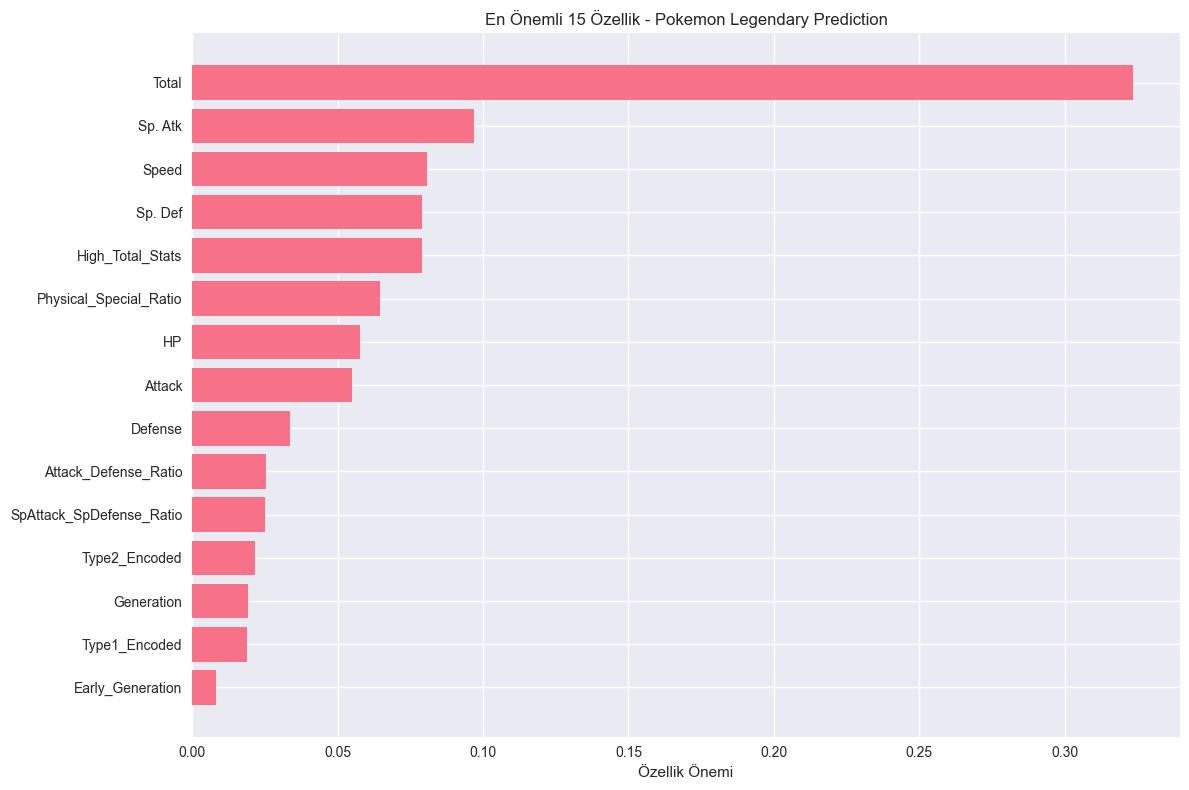

In [33]:
# Özellik önemini analiz etme
feature_importance = best_model.feature_importances_
feature_names = X.columns

# Özellik önem sıralaması
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("ÖZELLİK ÖNEMİ SIRALAMASI:")
print("="*40)
for i, (_, row) in enumerate(importance_df.head(15).iterrows(), 1):
    print(f"{i:2d}. {row['feature']:<25} {row['importance']:.4f}")

# Özellik önemini görselleştirme
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Özellik Önemi')
plt.title('En Önemli 15 Özellik - Pokemon Legendary Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


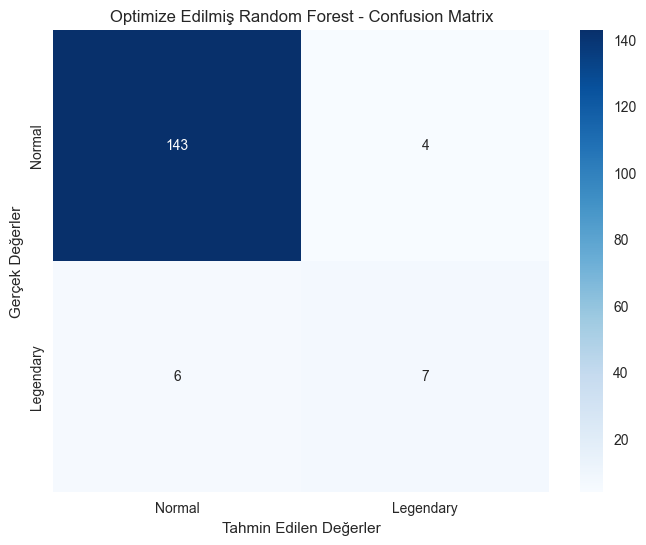


DETAYLI SINIFLANDIRMA RAPORU:
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97       147
   Legendary       0.64      0.54      0.58        13

    accuracy                           0.94       160
   macro avg       0.80      0.76      0.77       160
weighted avg       0.93      0.94      0.94       160



In [34]:
# Final confusion matrix
plt.figure(figsize=(8, 6))
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Legendary'], 
            yticklabels=['Normal', 'Legendary'])
plt.title('Optimize Edilmiş Random Forest - Confusion Matrix')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Detaylı classification report
print("\nDETAYLI SINIFLANDIRMA RAPORU:")
print("="*50)
print(classification_report(y_test, y_pred_optimized, 
                          target_names=['Normal', 'Legendary']))


In [35]:
# Örnek tahminler - en yüksek ve en düşük olasılıklı Pokemon'lar
prediction_df = pd.DataFrame({
    'Pokemon_Index': X_test.index,
    'Actual_Legendary': y_test,
    'Predicted_Legendary': y_pred_optimized,
    'Legendary_Probability': y_pred_proba_optimized
})

# Orijinal veri ile birleştir
prediction_with_names = prediction_df.merge(
    df[['Name', 'Type 1', 'Type 2', 'Total']].reset_index(), 
    left_on='Pokemon_Index', right_on='index', how='left'
)

print("EN YÜKSEK LEGENDARY OLASILIĞI (Tahmin edilen):")
print("="*60)
high_prob = prediction_with_names.nlargest(10, 'Legendary_Probability')
for _, row in high_prob.iterrows():
    status = "✓" if row['Actual_Legendary'] else "✗"
    print(f"{row['Name']:<20} {row['Legendary_Probability']:.3f} {status}")

print(f"\nEN DÜŞÜK LEGENDARY OLASILIĞI (Tahmin edilen):")
print("="*60)
low_prob = prediction_with_names.nsmallest(10, 'Legendary_Probability')
for _, row in low_prob.iterrows():
    status = "✓" if not row['Actual_Legendary'] else "✗"
    print(f"{row['Name']:<20} {row['Legendary_Probability']:.3f} {status}")


EN YÜKSEK LEGENDARY OLASILIĞI (Tahmin edilen):
Xerneas              0.890 ✓
Palkia               0.830 ✓
Manaphy              0.796 ✗
MewtwoMega Mewtwo X  0.687 ✓
Cresselia            0.671 ✗
DeoxysNormal Forme   0.659 ✓
Mew                  0.634 ✗
ThundurusTherian Forme 0.589 ✓
GardevoirMega Gardevoir 0.548 ✗
Darkrai              0.527 ✓

EN DÜŞÜK LEGENDARY OLASILIĞI (Tahmin edilen):
Seaking              0.000 ✓
Patrat               0.000 ✓
Minun                0.000 ✓
Petilil              0.000 ✓
Braviary             0.000 ✓
Floette              0.000 ✓
Furret               0.000 ✓
Venipede             0.000 ✓
Palpitoad            0.000 ✓
Nidoran♀             0.000 ✓
